# nanoGPT — character-level language modelling

Sven (Gram backend) against the modern LM optimizers — AdamW, Muon, MuonW, SOAP — on
char-level tiny-shakespeare, with the three result-dependent passes the campaign ran for
every headline scan: `_confirm` (5 fresh model seeds), `_timing` (each selected
configuration alone on a GPU, logging off) and `_diag`.

This is the *small* transformer evidence; `gpt2_analysis.ipynb` is the large one, and the
two say different things, which is the point of having both.

Every table here comes from `analysis/lib/headline.py`, driven by `bench/best_configs.json` —
the selection of record, made on the seed-mean final **validation** loss under the binding
rule (eligible → fewest diverged → seed mean). Test numbers are outcomes of that
configuration and never selected on.

In [1]:
import sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import os
# This notebook lives in analysis/notebooks/<group>/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))
from pathlib import Path
from style import (load_results, set_style, DATASET_TITLES, method_label, method_color,
                   seed_spread_label, band_legend)
from analysis_helpers import add_derived
import scan_analysis as sa
import headline as hl
import large_figs as lf
set_style()
pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 60)

PLOT_DIR = Path('plots_v2/nanogpt'); PLOT_DIR.mkdir(parents=True, exist_ok=True)
SCAN = 'exp_nanogpt_speedrun'
TITLE = DATASET_TITLES['nanogpt']

def show(df, title=None):
    return hl.print_table(df, title)

print('selection of record:', hl.SELECTION_PATH, '|', hl.load_selection()['generated_at'])
print('selections checked (validation-only assertion):',
      hl.assert_no_test_selection(scans=[SCAN]))
fresh = hl.freshness_report(scans=[SCAN])
show(fresh, 'freshness')
print('PROVISIONAL' if fresh.attrs['provisional_scans'] else
      'settled: nothing is still landing in this scan.')

selection of record: /n/home/anon/sven-experiments/bench/best_configs.json | 2026-09-20T22:06:52-0400
selections checked (validation-only assertion): 5

### freshness
| scan | pass | selection_input | n_records | newest_record | n_after_selection | n_claims_live | provisional |
|---|---|---|---|---|---|---|---|
| exp_nanogpt_speedrun | scan | True | 140 | 2026-09-19 13:05:43 | 0 | 0 | False |
| exp_nanogpt_speedrun | confirm | False | 25 | 2026-09-20 11:29:55 | 0 | 0 | False |
| exp_nanogpt_speedrun | timing | False | 25 | 2026-09-20 09:10:51 | 0 | 0 | False |
settled: nothing is still landing in this scan.


## 1. The confirmation table

Mean ± 1 std over the 5 fresh model seeds, with the tuning seeds beside them. `train (eval
mode)` is the training loss of the trained model in eval mode on a fixed subset, so
"optimised but did not generalise" and "did not optimise" are distinguishable.

In [2]:
CONF = hl.confirmation_table(SCAN)
show(hl.confirmation_view(CONF), f'{TITLE} — confirmation seeds (rank order)')
show(lf.optimisation_view(CONF), f'{TITLE} — optimisation vs generalisation')

val = pd.to_numeric(CONF['val_conf'], errors='coerce')
n = int(np.isfinite(val).sum())
sven = CONF[CONF.method == 'Sven'].iloc[0]
rank_val = int(val.rank(method='min')[CONF.method.eq('Sven')].iloc[0])
rank_test = int(pd.to_numeric(CONF['test_conf'], errors='coerce')
                .rank(method='min')[CONF.method.eq('Sven')].iloc[0])
print(f'\nSven: {rank_val} of {n} on validation, {rank_test} of {n} on test '
      f'({sven["config"]}); val {sven["val_conf"]:.4g} ± {sven["val_conf_std"]:.3g}, '
      f'perplexity {np.exp(sven["val_conf"]):.4g}.')
ppl = pd.DataFrame({'method': CONF['display'], 'val': val,
                    'val ppl': np.exp(val),
                    'test': pd.to_numeric(CONF['test_conf'], errors='coerce'),
                    'test ppl': np.exp(pd.to_numeric(CONF['test_conf'], errors='coerce')),
                    'finished/attempted': [hl.fmt_counts(a, b) for a, b in
                                           zip(CONF['fin_conf'], CONF['att_conf'])]})
show(ppl, f'{TITLE} — loss and perplexity (confirmation seeds)')

Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_confirm.slim.pkl (slim cache)

### nanoGPT (tiny-shakespeare) — confirmation seeds (rank order)
| method | config | val (confirm) | test (confirm) | train (eval mode) | finished/attempted | val (tuning) | tuning fin/att | gap (confirm-tune) | gap rel |
|---|---|---|---|---|---|---|---|---|---|
| AdamW | lr=0.0003, weight_decay=0.01 | 1.713 ± 0.01805 | 1.978 ± 0.02016 | 1.259 ± 0.01149 | 5/5 | 1.714 ± 0.01515 | 5/5 | -0.00159 | -0.1% |
| Sven | k=64, lr=0.1, rtol=0.001 | 1.715 ± 0.007961 | 1.977 ± 0.02441 | 1.306 ± 0.05544 | 5/5 | 1.724 ± 0.01887 | 5/5 | -0.008611 | -0.5% |
| MuonW | lr=0.0001, weight_decay=0.1 | 1.81 ± 0.002481 | 1.973 ± 0.006131 | 1.531 ± 0.003418 | 5/5 | 1.818 ± 0.005165 | 5/5 | -0.007322 | -0.4% |
| Muon | lr=0.0001 | 1.812 ± 0.002301 | 1.976 ± 0.005753 | 1.527 ± 0.003612 | 5/5 | 1.819 ± 0.005231 | 5/5 | -

,method,val,val ppl,test,test ppl,finished/attempted
0,AdamW,1.712837,5.544668,1.978235,7.229973,5/5
1,Sven,1.715018,5.556777,1.977320,7.223361,5/5
2,MuonW,1.810371,6.112716,1.972761,7.190499,5/5
3,Muon,1.811817,6.121557,1.975887,7.213017,5/5
4,SOAP,1.816764,6.151920,2.032622,7.634076,5/5


### Paired differences against Sven

Differenced within a model seed (same initialisation, same data order), so the
seed-to-seed variation that dominates the unpaired spread is removed. Negative = Sven has
the lower loss on that seed; `sven_better` counts the pairs Sven won.

In [3]:
show(hl.paired_vs_sven(SCAN), f'{TITLE} — paired Sven − other, validation loss')
print(hl.paired_vs_sven(SCAN).attrs['sign'])
t = hl.paired_outcome_vs_sven(SCAN, metric='final_test_loss')
show(t, f'{TITLE} — paired Sven − other, test loss')
print(t.attrs['sign'])


### nanoGPT (tiny-shakespeare) — paired Sven − other, validation loss
| method | display | reference | metric | n | mean | std | sem | ci_low | ci_high | half_width | level | mean_a | mean_b | n_unpaired | a_better | significant | sven_better |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| SOAP | SOAP | Sven | final_val_loss | 5 | -0.1017 | 0.01278 | 0.005718 | -0.1176 | -0.08587 | 0.01587 | 0.95 | 1.715 | 1.817 | 0 | 5 | True | 5 |
| Muon | Muon | Sven | final_val_loss | 5 | -0.0968 | 0.008323 | 0.003722 | -0.1071 | -0.08646 | 0.01033 | 0.95 | 1.715 | 1.812 | 0 | 5 | True | 5 |
| MuonW | MuonW | Sven | final_val_loss | 5 | -0.09535 | 0.00867 | 0.003877 | -0.1061 | -0.08459 | 0.01077 | 0.95 | 1.715 | 1.81 | 0 | 5 | True | 5 |
| AdamW | AdamW | Sven | final_val_loss | 5 | 0.002182 | 0.01994 | 0.008919 | -0.02258 | 0.02695 | 0.02476 | 0.95 | 1.715 | 1.713 | 0 | 3 | False | 3 |
mean = Sven - other in final_val_loss (a loss): NEGATIVE means Sven is better; sv


### nanoGPT (tiny-shakespeare) — paired Sven − other, test loss
| method | display | reference | metric | n | mean | std | sem | ci_low | ci_high | half_width | level | n_unpaired | sven_better | significant |
|---|---|---|---|---|---|---|---|---|---|---|---|---|---|---|
| SOAP | SOAP | Sven | final_test_loss | 5 | -0.0553 | 0.02699 | 0.01207 | -0.08882 | -0.02178 | 0.03352 | 0.95 | 0 | 5 | True |
| AdamW | AdamW | Sven | final_test_loss | 5 | -0.0009149 | 0.03123 | 0.01397 | -0.03969 | 0.03786 | 0.03878 | 0.95 | 0 | 3 | False |
| Muon | Muon | Sven | final_test_loss | 5 | 0.001433 | 0.02574 | 0.01151 | -0.03053 | 0.0334 | 0.03196 | 0.95 | 0 | 2 | False |
| MuonW | MuonW | Sven | final_test_loss | 5 | 0.00456 | 0.02616 | 0.0117 | -0.02792 | 0.03704 | 0.03248 | 0.95 | 0 | 2 | False |
mean = Sven - other in final_test_loss; NEGATIVE means Sven is better (a loss); sven_better counts the pairs Sven won


## 2. Convergence: against optimizer steps and against time

The two rows are two **passes on two seed sets**, and the figure says which is which.

* Top (step axis): the selected configuration's runs in `{scan}_confirm` — the same runs,
  the same seeds, as the table above, so these curves cannot drift away from it. The step
  axis is `epoch × steps_per_epoch`.
* Bottom (time axis): `{scan}_timing`, the standalone pass, because the confirmation runs
  shared their GPU and their wall clock prices the queue rather than the optimizer. That
  pass re-runs the **tuning** seeds (base+0..4), not the confirmation seeds (base+100..104),
  so it describes the same configuration on different initialisations; `large_figs.seed_note`
  prints both seed sets on the figure.


Loaded 25 runs from ../experiment_results/_cache/exp_nanogpt_speedrun_timing.slim.pkl (slim cache)


plots_v2/nanogpt/nanogpt_curves.pdf


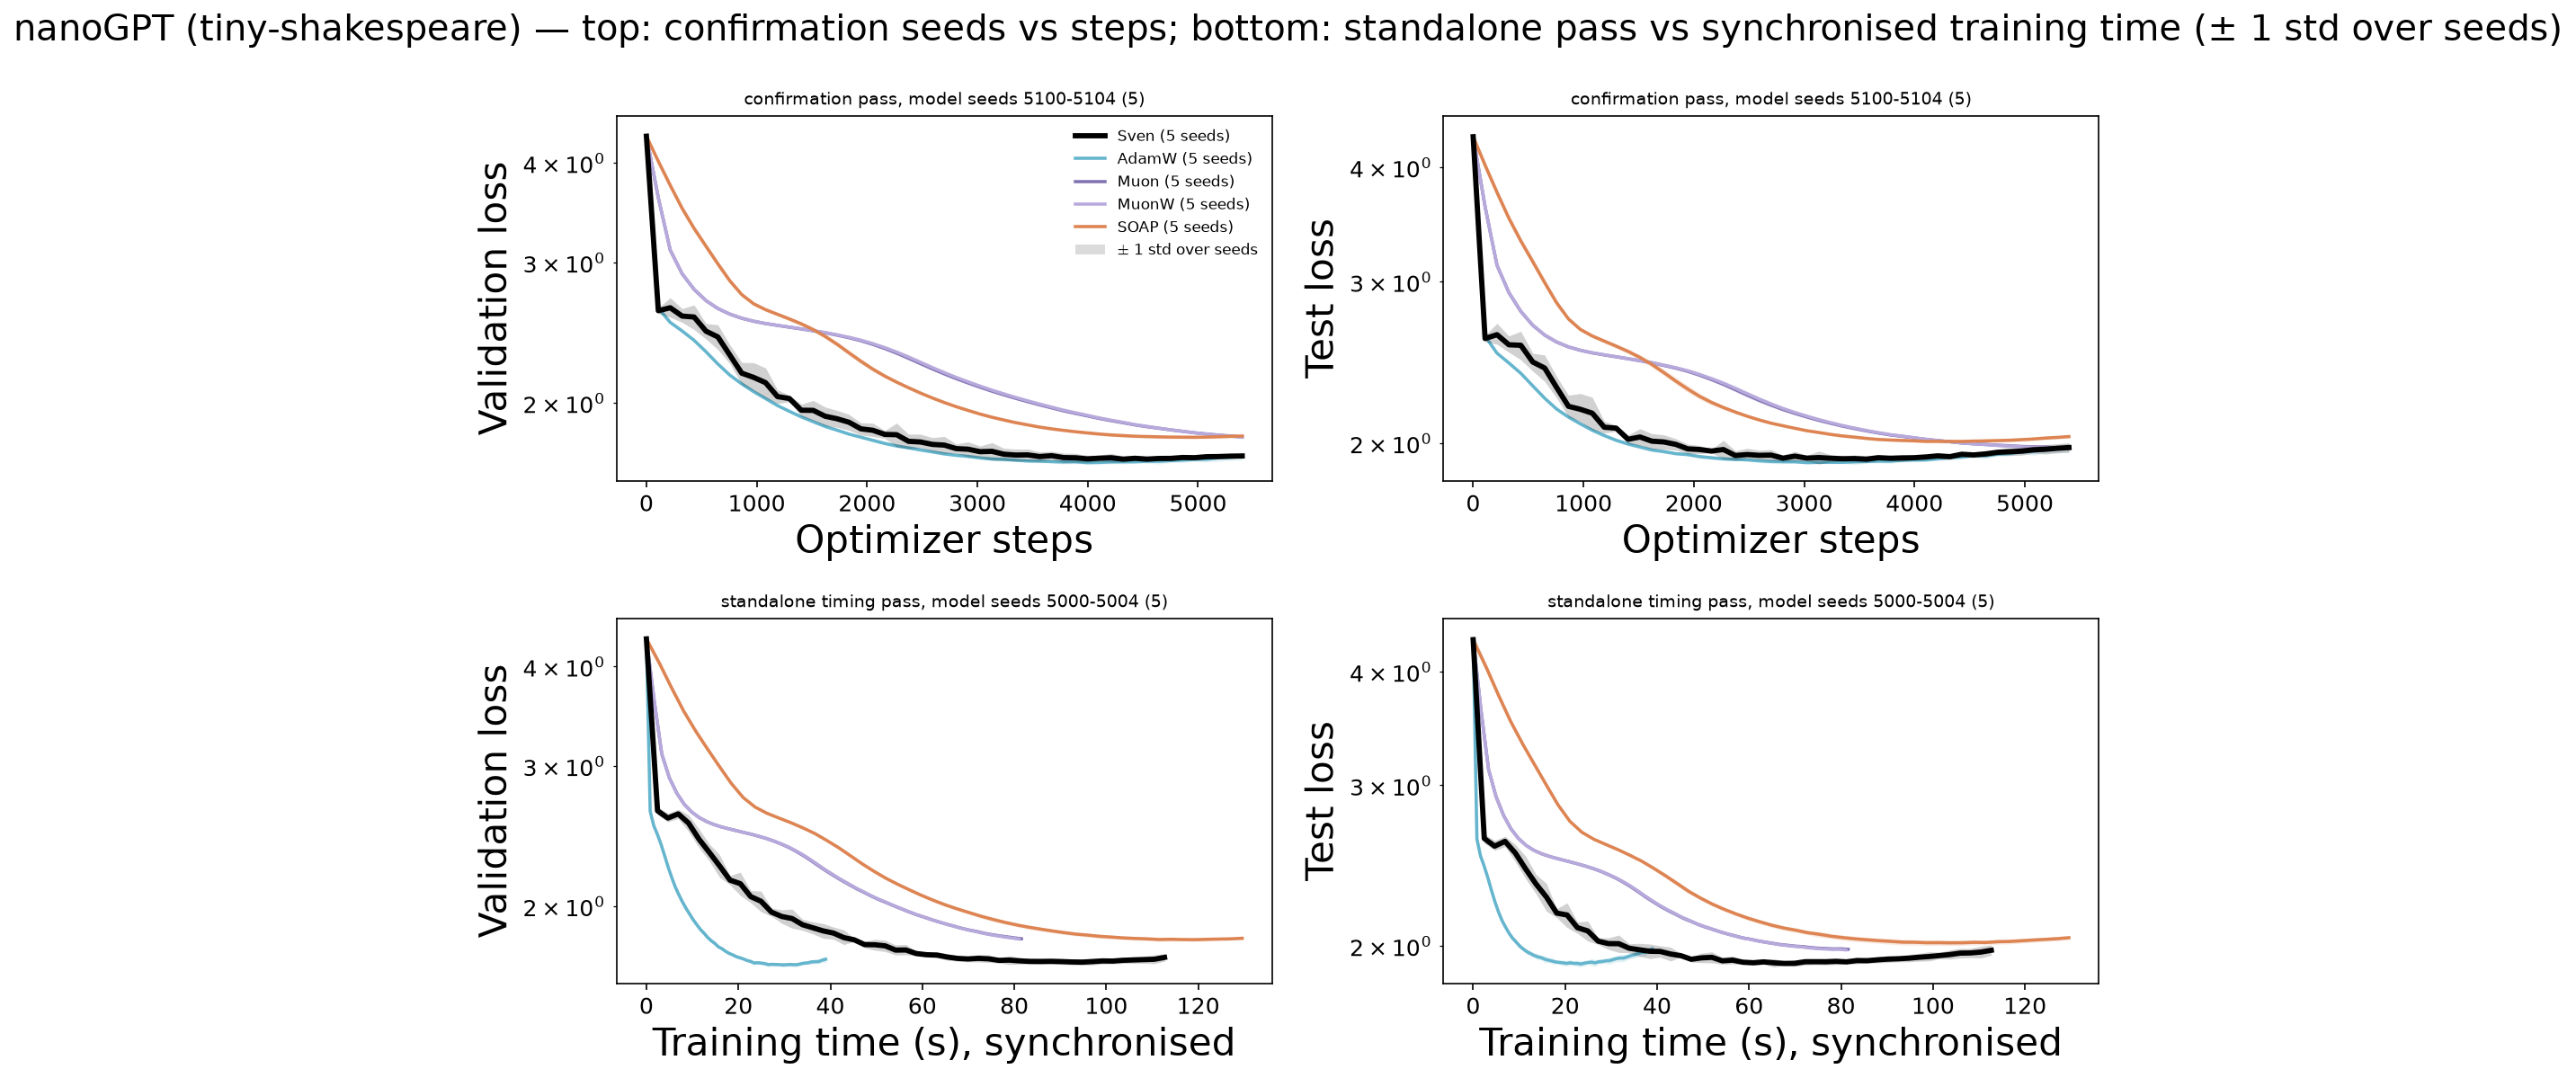

In [4]:
RUNS_CONF = lf.selected_runs_by_method(SCAN, 'confirm')
RUNS_TIME = lf.selected_runs_by_method(SCAN, 'timing')

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.2))
for ax, key in zip(axes[0], ('val', 'test')):
    lf.plot_curves(ax, RUNS_CONF, key, versus='step')
for ax, key in zip(axes[1], ('val', 'test')):
    lf.plot_curves(ax, RUNS_TIME, key, versus='time', time_key='train_times')
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_title(f'confirmation pass, {lf.seed_note(RUNS_CONF)}', fontsize=9)
axes[0, 1].set_title(f'confirmation pass, {lf.seed_note(RUNS_CONF)}', fontsize=9)
axes[1, 0].set_title(f'standalone timing pass, {lf.seed_note(RUNS_TIME)}', fontsize=9)
axes[1, 1].set_title(f'standalone timing pass, {lf.seed_note(RUNS_TIME)}', fontsize=9)
fig.suptitle(f'{TITLE} — top: confirmation seeds vs steps; bottom: standalone pass vs '
             f'synchronised training time ({seed_spread_label(plain=True)})')
fig.tight_layout()
print(lf.savefig(fig, 'nanogpt_curves', PLOT_DIR)[0])
plt.show()


plots_v2/nanogpt/nanogpt_train_eval.pdf


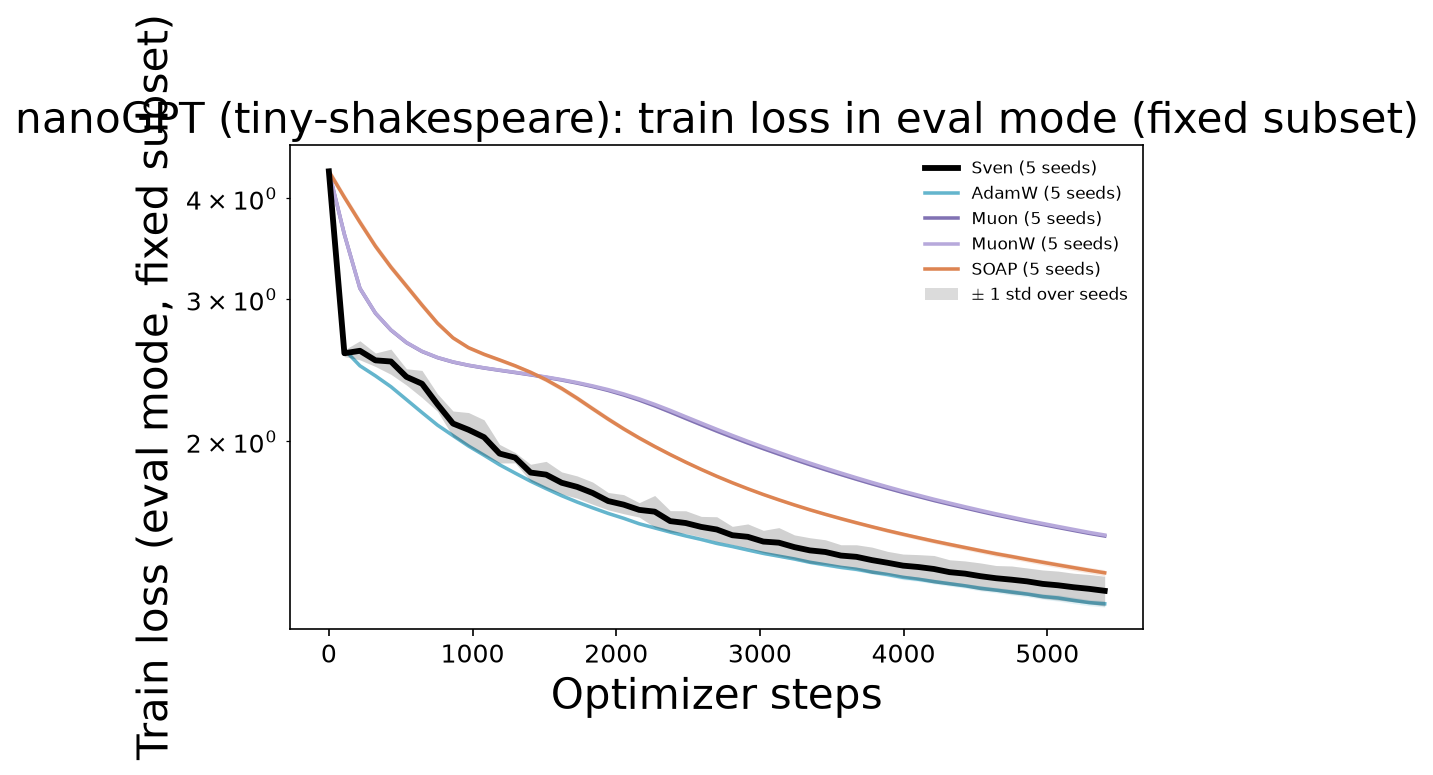

In [5]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
lf.plot_curves(ax, RUNS_CONF, 'train_eval', versus='step')
ax.set_title(f'{TITLE}: train loss in eval mode (fixed subset)')
ax.legend(fontsize=8)
fig.tight_layout()
print(lf.savefig(fig, 'nanogpt_train_eval', PLOT_DIR)[0])
plt.show()

## 3. Sven's grid on this scan

`k = 64` at `B = 64` is `k = B` — the uncapped-rank configuration, a natural maximum
rather than a grid edge — and `rtol` was swept at one value here, so the whole Sven search
is over the learning rate. The table says how much of the grid that is.

Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
exp_nanogpt_speedrun: 140 runs  |  B=64, 50 epochs, 5 seeds  |  Sven k=[64] rtol=[0.001]
  manifest: 140 of 140 intended runs present, 0 with no record

### nanoGPT (tiny-shakespeare) — every Sven configuration
| k | lr | rtol | val | val_std | val_min | finished | attempted | n_diverged | n_failed | n_missing | eligible | selected |
|---|---|---|---|---|---|---|---|---|---|---|---|---|
| 64 | 0.1 | 0.001 | 1.724 | 0.01887 | 1.698 | 5 | 5 | 0 | 0 | 0 | True | True |
| 64 | 0.05 | 0.001 | 1.818 | 0.04148 | 1.792 | 5 | 5 | 0 | 0 | 0 | True | False |
| 64 | 0.5 | 0.001 | 3.366 | 0.5164 | 2.887 | 5 | 5 | 0 | 0 | 0 | True | False |
| 64 | 1 | 0.001 | 4.665 | 1.739 | 3.36 | 5 | 5 | 0 | 0 | 0 | True | False |
  selected: k=64, lr=0.1, rtol=0.001
  k = B = 64: the uncapped-rank point, a natural maximum, not an edge
  Sven divergences on this grid: 0 of 20 runs recorded = all 20 intended


Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)
exp_nanogpt_speedrun: 140 runs  |  B=64, 50 epochs, 5 seeds  |  Sven k=[64] rtol=[0.001]
  manifest: 140 of 140 intended runs present, 0 with no record


plots_v2/nanogpt/nanogpt_sven_lr_sensitivity.pdf


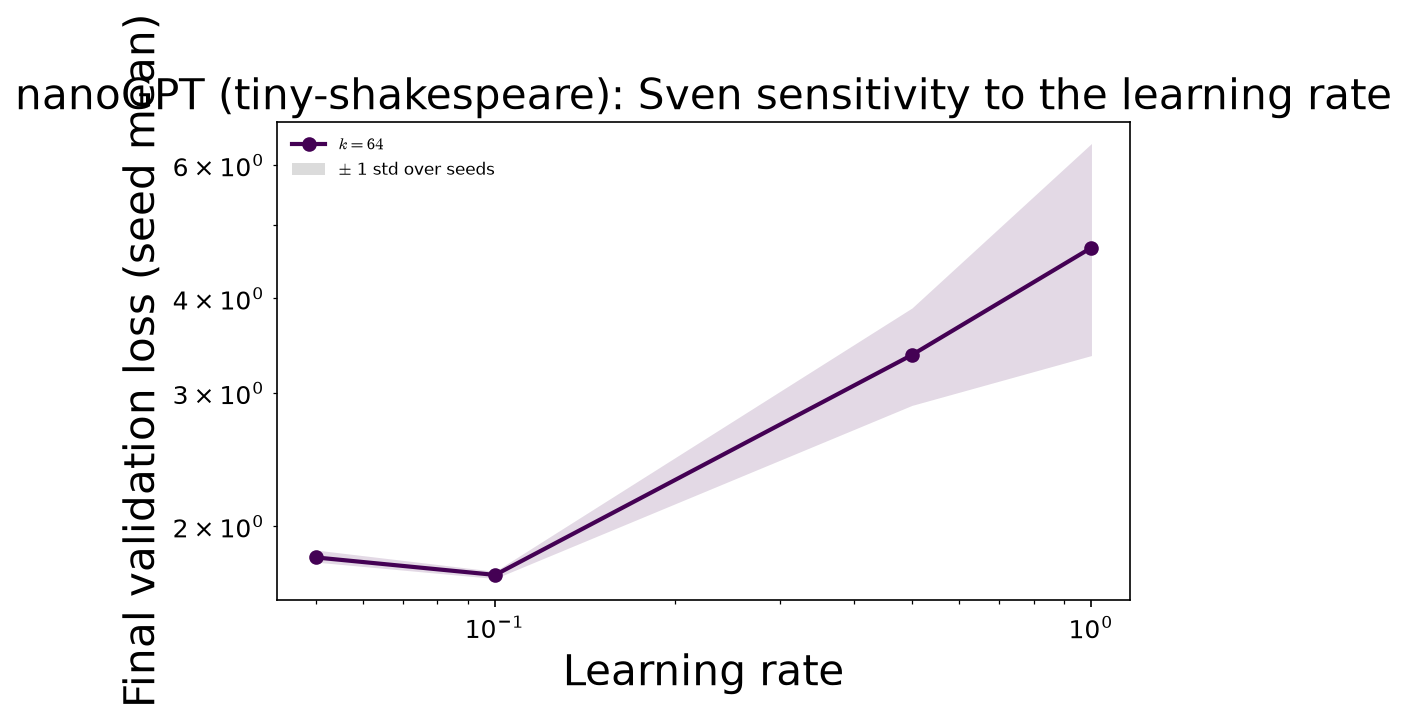

In [6]:
GRID = lf.mark_selected(lf.sven_grid(SCAN), SCAN)
show(GRID, f'{TITLE} — every Sven configuration')
sel = GRID[GRID['selected']]
if len(sel):
    s = sel.iloc[0]
    print(f'  selected: k={s["k"]:g}, lr={s["lr"]:g}, rtol={s["rtol"]:g}')
    print(f'  k = B = {int(s["k"])}: the uncapped-rank point, a natural maximum, not an edge')
# Counted over the runs that HAVE A RECORD: `attempted` is the manifest count, so a grid
# with runs still to start would otherwise count those as clean (EXPERIMENTS.md section 7).
d = lf.grid_divergence_counts(GRID)
print(f'  Sven divergences on this grid: {d["diverged"]} of {d["recorded"]} runs recorded'
      + (f'; {d["missing"]} of the {d["attempted"]} intended not started yet'
         if d['missing'] else f' = all {d["attempted"]} intended'))

scan_obj = lf.load_scan_obj(SCAN, plot_dir=PLOT_DIR)
fig, ax = plt.subplots(figsize=(7.2, 4.6))
sa.plot_sensitivity(scan_obj, ax, x='lr', lines='k', third='best')
ax.set_title(f'{TITLE}: Sven sensitivity to the learning rate')
ax.legend(fontsize=8)
fig.tight_layout()
print(lf.savefig(fig, 'nanogpt_sven_lr_sensitivity', PLOT_DIR)[0])
plt.show()


## 4. Cost, tuning budget, and time to a pre-declared target

Times and memory from `{scan}_timing` (standalone). The targets are declared from
validation only, once, as the median method's confirmation-seed final validation loss and
2× / 0.5× of it — so no target can be chosen after seeing who reaches it. Runs that never
reach one are counted, not dropped.


### nanoGPT (tiny-shakespeare) — cost of the selected configuration (standalone)
| method | config | s/epoch | x fastest | ms/step | peak mem (MB) | x leanest | total wall (s) | fin/att | GPU |
|---|---|---|---|---|---|---|---|---|---|
| AdamW | lr=0.0003, weight_decay=0.01 | 0.9139 ± 0.002744 | 1.00x | 7.22 | 329.67 ± 0 | 1.01x | 45.704 | 5/5 | NVIDIA A100-SXM4-80GB |
| MuonW | lr=0.0001, weight_decay=0.1 | 1.754 ± 0.005388 | 1.92x | 15.01 | 326.53 ± 0 | 1.00x | 87.689 | 5/5 | NVIDIA A100-SXM4-80GB |
| Muon | lr=0.0001 | 1.765 ± 0.005018 | 1.93x | 15.1 | 326.53 ± 0 | 1.00x | 88.245 | 5/5 | NVIDIA A100-SXM4-80GB |
| Sven | k=64, lr=0.1, rtol=0.001 | 2.404 ± 0.004986 | 2.63x | 20.86 | 615.45 ± 0 | 1.88x | 120.21 | 5/5 | NVIDIA A100-SXM4-80GB |
| SOAP | lr=0.0001 | 2.73 ± 0.006679 | 2.99x | 23.99 | 352.29 ± 0 | 1.08x | 136.51 | 5/5 | NVIDIA A100-SXM4-80GB |
  times from: exp_nanogpt_speedrun_timing | co-tenancy on the same GPU



### nanoGPT (tiny-shakespeare) — tuning budget: distinct trajectories per method
| label | grid_points | distinct | distinct_frac | n_diverged |
|---|---|---|---|---|
| AdamW | 6 | 6 | 1 | 0 |
| MuonW | 6 | 6 | 1 | 0 |
| Muon | 6 | 6 | 1 | 0 |
| SOAP | 6 | 6 | 1 | 0 |
| Sven | 4 | 4 | 1 | 0 |


plots_v2/nanogpt/nanogpt_cost.pdf


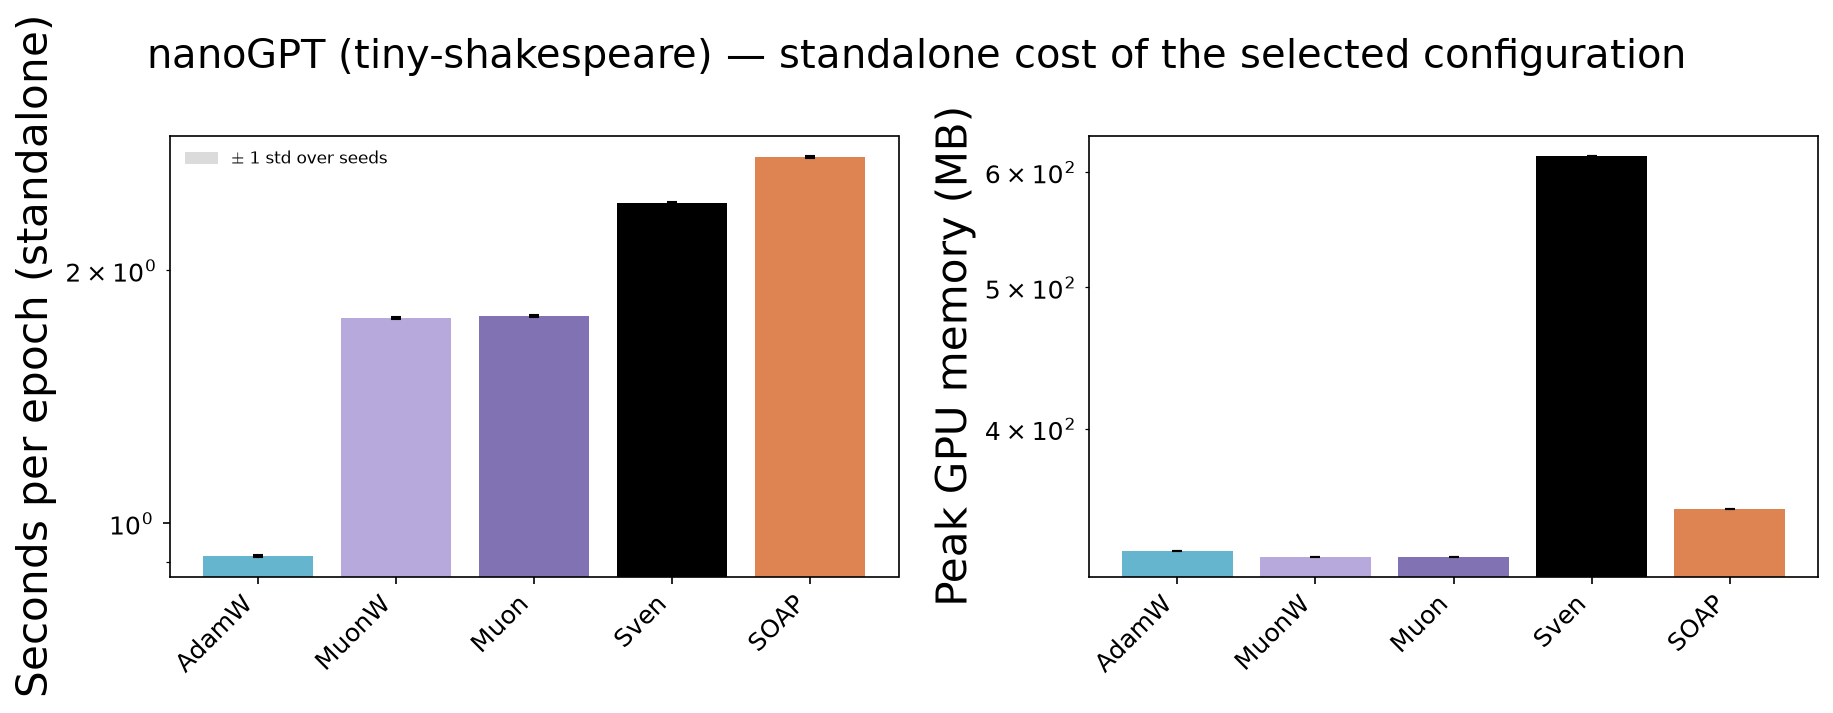

In [7]:
EFF = hl.efficiency_table(SCAN)
show(lf.cost_view(EFF), f'{TITLE} — cost of the selected configuration (standalone)')
print('  times from:', EFF.attrs['times_from'], '|', EFF.attrs['inflation_means'])

b = hl.budget_table(SCAN)
show(b[['label', 'grid_points', 'distinct', 'distinct_frac', 'n_diverged']],
     f'{TITLE} — tuning budget: distinct trajectories per method')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
lf.plot_cost_bars(axes, EFF)
fig.suptitle(f'{TITLE} — standalone cost of the selected configuration')
fig.tight_layout()
print(lf.savefig(fig, 'nanogpt_cost', PLOT_DIR)[0])
plt.show()

In [8]:
tt = hl.time_to_target_table(SCAN)
for label, sub in tt.groupby('target', sort=False):
    cols = ['display', 'epochs', 'steps', 'sync_train_s', 'standalone_s', 'n_reached',
            'n_never_reached', 'n_diverged', 'n_runs']
    show(sub[cols].sort_values('epochs', na_position='last').reset_index(drop=True),
         f'{TITLE} — time to target: {label} '
         f'(val = {tt.attrs["targets"][label]:.4g})')


### nanoGPT (tiny-shakespeare) — time to target: easy (2x median) (val = 3.621)
| display | epochs | steps | sync_train_s | standalone_s | n_reached | n_never_reached | n_diverged | n_runs |
|---|---|---|---|---|---|---|---|---|
| Sven | 1 | 108 | 5.982 | 2.404 | 5 | 0 | 0 | 5 |
| AdamW | 1 | 108 | 2.28 | 0.9139 | 5 | 0 | 0 | 5 |
| Muon | 1.6 | 172.8 | 5.14 | 2.823 | 5 | 0 | 0 | 5 |
| MuonW | 1.6 | 172.8 | 4.957 | 2.806 | 5 | 0 | 0 | 5 |
| SOAP | 3 | 324 | 16.62 | 8.19 | 5 | 0 | 0 | 5 |

### nanoGPT (tiny-shakespeare) — time to target: median method (val = 1.81)
| display | epochs | steps | sync_train_s | standalone_s | n_reached | n_never_reached | n_diverged | n_runs |
|---|---|---|---|---|---|---|---|---|
| AdamW | 18.4 | 1987 | 40.09 | 16.81 | 5 | 0 | 0 | 5 |
| Sven | 21.6 | 2333 | 119.5 | 51.92 | 5 | 0 | 0 | 5 |
| SOAP | 43.67 | 4716 | 231.2 | 119.2 | 3 | 2 | 0 | 5 |
| Muon | 50 | 5400 | 122.2 | 88.23 | 1 | 4 | 0 | 5 |
| MuonW | 50 | 5400 | 149.8 | 87.68 | 2 | 3 | 0 | 5 |

### na

## 5. Did the standalone pass reproduce the scan?

Same run_ids, same seeds, hence the same initialisation and data order — but GPU kernels
are not bit-exact across GPU types, and Muon's bf16 Newton–Schulz, L-BFGS and SOAP are
expected to deviate. `max_rel_dev_raw` is the quantity `bench/check_timing_join.py`
reports; `bit_reproduced` also requires that no run diverged on exactly one side.

In [9]:
show(hl.timing_join_report(SCAN), f'{TITLE} — scan vs standalone timing pass')
cal = hl.calibration_report(scans=[SCAN])
cal = cal[cal['scan'] == SCAN] if len(cal) else cal   # the log dir holds all seven jobs
if len(cal):
    show(cal, 'calibration of this timing job (bench/calibrate_step.py, start vs end)')
    print('threshold for "contaminated": |drift| >', hl.calibration_report().attrs['threshold'])
else:
    print('no calibration lines readable from here:', cal.attrs.get('note'))


### nanoGPT (tiny-shakespeare) — scan vs standalone timing pass
| method | display | n_timing | n_joined | max_rel_dev | median_rel_dev | bit_reproduced | n_diverged_only_in_timing | n_diverged_only_in_scan | max_rel_dev_raw | worst_run_raw |
|---|---|---|---|---|---|---|---|---|---|---|
| Sven | Sven | 5 | 5 | 0 | 0 | True | 0 | 0 | 0 | svd_bs64_k64_lr0.1_rtol0.001_svdtorch_mseed5000_lseed5000_gram |
| AdamW | AdamW | 5 | 5 | 0 | 0 | True | 0 | 0 | 0 | std_bs64_lr0.0003_optimAdamW_wd0.01_mseed5000_lseed5000 |
| Muon | Muon | 5 | 5 | 0 | 0 | True | 0 | 0 | 0 | std_bs64_lr0.0001_optimMuon_mseed5000_lseed5000 |
| MuonW | MuonW | 5 | 5 | 0 | 0 | True | 0 | 0 | 0 | std_bs64_lr0.0001_optimMuonW_wd0.1_mseed5000_lseed5000 |
| SOAP | SOAP | 5 | 5 | 0 | 0 | True | 0 | 0 | 0 | std_bs64_lr0.0001_optimSOAP_mseed5000_lseed5000 |

### calibration of this timing job (bench/calibrate_step.py, start vs end)
| scan | job | host | gpu | start_ms | end_ms | drift | start_loadavg | end_loadavg | contamina

## 6. The framing, computed

Nothing below is typed in; it is recomputed from the tables above.

In [10]:
e = EFF.set_index('method')
val = pd.to_numeric(CONF['val_conf'], errors='coerce')
test = pd.to_numeric(CONF['test_conf'], errors='coerce')
n = int(np.isfinite(val).sum())
sven = CONF[CONF.method == 'Sven'].iloc[0]
rank_val = int(val.rank(method='min')[CONF.method.eq('Sven')].iloc[0])
rank_test = int(test.rank(method='min')[CONF.method.eq('Sven')].iloc[0])
best = CONF.iloc[0]
print(f'### {TITLE}')
print(f'* Sven is **{rank_val} of {n}** on validation loss and **{rank_test} of {n}** on '
      f'test loss (confirmation seeds, '
      f'{hl.fmt_counts(sven["fin_conf"], sven["att_conf"])}); '
      f'{best["display"]} leads at {best["val_conf"]:.4g}, Sven '
      f'{sven["val_conf"]:.4g} ({100 * (sven["val_conf"] / best["val_conf"] - 1):+.1f}%).')
print(f'* Perplexity: Sven {np.exp(sven["val_conf"]):.3g} val / '
      f'{np.exp(sven["test_conf"]):.3g} test.')
print(f'* Cost: **{e.loc["Sven", "epoch_s"]:.2f} s/epoch** against '
      f'{e["epoch_s"].drop("Sven").min():.2f}–{e["epoch_s"].drop("Sven").max():.2f} s, '
      f'peak memory {e.loc["Sven", "peak_gpu_mem_mb"]:.0f} MB against '
      f'{e["peak_gpu_mem_mb"].drop("Sven").min():.0f}–'
      f'{e["peak_gpu_mem_mb"].drop("Sven").max():.0f} MB, '
      f'{e.loc["Sven", "ms_per_step"]:.1f} ms/step against '
      f'{e["ms_per_step"].drop("Sven").min():.1f}–'
      f'{e["ms_per_step"].drop("Sven").max():.1f} ms.')
print(f'* Selection optimism: {sven["gap_val_rel"]:+.1%} for Sven on this scan '
      f'(median over methods '
      f'{np.nanmedian(pd.to_numeric(CONF["gap_val_rel"], errors="coerce")):+.1%}).')
print(f'* Robustness: Sven diverged on {int(GRID["n_diverged"].sum())} of '
      f'{int(GRID["attempted"].sum())} runs of its grid here — one of the few scans where '
      f'it has none, which is the defensible version of the claim.')
print(f'* Tuning budget: Sven searched {int(b.set_index("label").loc["Sven", "grid_points"])} '
      f'grid points against '
      f'{int(b.set_index("label").loc["AdamW", "grid_points"])} for AdamW; at an equal '
      f'budget see the best-of-n table in headline_tables.ipynb.')

### nanoGPT (tiny-shakespeare)
* Sven is **2 of 5** on validation loss and **3 of 5** on test loss (confirmation seeds, 5/5); AdamW leads at 1.713, Sven 1.715 (+0.1%).
* Perplexity: Sven 5.56 val / 7.22 test.
* Cost: **2.40 s/epoch** against 0.91–2.73 s, peak memory 615 MB against 327–352 MB, 20.9 ms/step against 7.2–24.0 ms.
* Selection optimism: -0.5% for Sven on this scan (median over methods -0.4%).
* Robustness: Sven diverged on 0 of 20 runs of its grid here — one of the few scans where it has none, which is the defensible version of the claim.
* Tuning budget: Sven searched 4 grid points against 6 for AdamW; at an equal budget see the best-of-n table in headline_tables.ipynb.
